In [24]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay

In [25]:
df = pd.read_csv("/kaggle/input/datasets/dakshsahni567/cleaned-iris/cleaned_dirty_iris.csv")

In [26]:
X = df.drop("species",axis = 1)
y = df["species"]

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state = 2026,test_size = 0.2,stratify = y)

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [37]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter = 500),
    "Decision Tree": DecisionTreeClassifier(random_state = 2026),
    "Random Forest": RandomForestClassifier(random_state = 2026),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

In [38]:
result_df = pd.DataFrame(columns = ["Model","Accuracy",'F1 Score','Precision','Recall'])

In [39]:
result_df

,Model,Accuracy,F1 Score,Precision,Recall


In [40]:
def runModel(model):
    currModel = models[model].fit(X_train,y_train)
    pred = currModel.predict(X_test)
    new_row = {
        "Model": model,
        "Accuracy": accuracy_score(y_test,pred),
        "Precision": precision_score(y_test,pred,average ="weighted"),
        "Recall":recall_score(y_test,pred,average = "weighted"),
        "F1 Score": f1_score(y_test,pred,average = "weighted")
    }
    cm = confusion_matrix(y_test,pred)
    disp = ConfusionMatrixDisplay(confusion_matrix = cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model}")
    result_df.loc[len(result_df)] =  new_row

,Model,Accuracy,F1 Score,Precision,Recall
0,Logistic Regression,0.866667,0.861111,0.904762,0.866667
1,Decision Tree,0.966667,0.966583,0.969697,0.966667
2,Random Forest,0.966667,0.966583,0.969697,0.966667
3,KNN,0.866667,0.861111,0.904762,0.866667
4,SVM,0.800000,0.794422,0.875000,0.800000


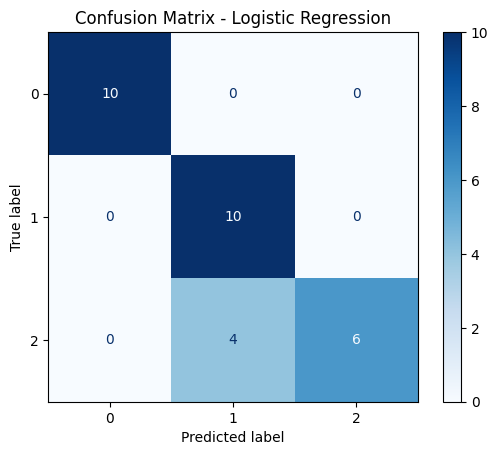

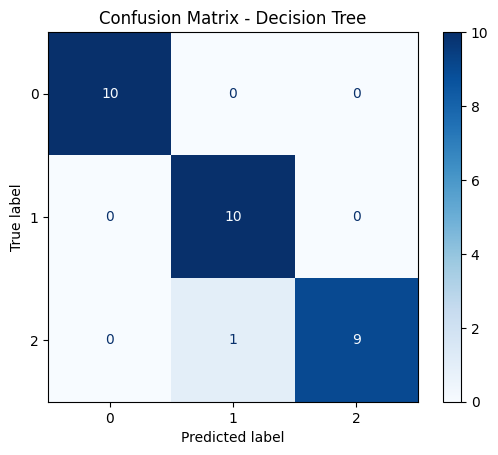

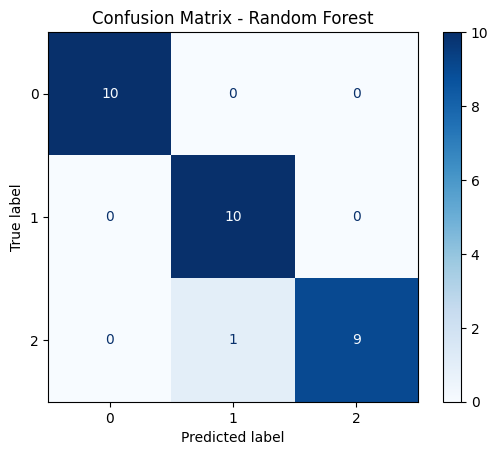

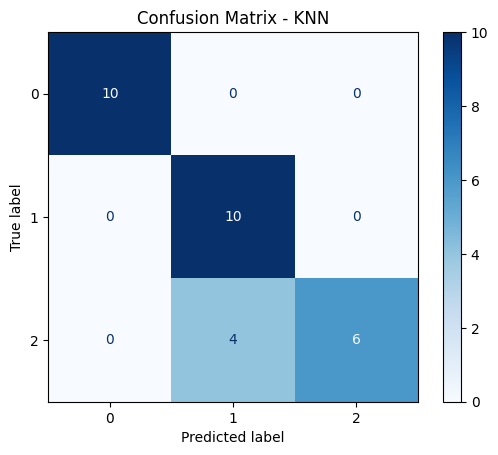

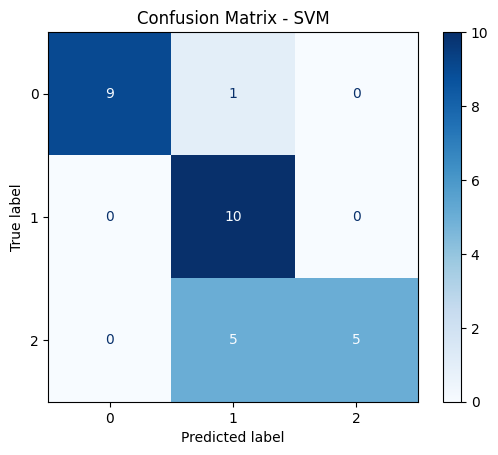

In [41]:
for model in models:
    runModel(model)

result_df

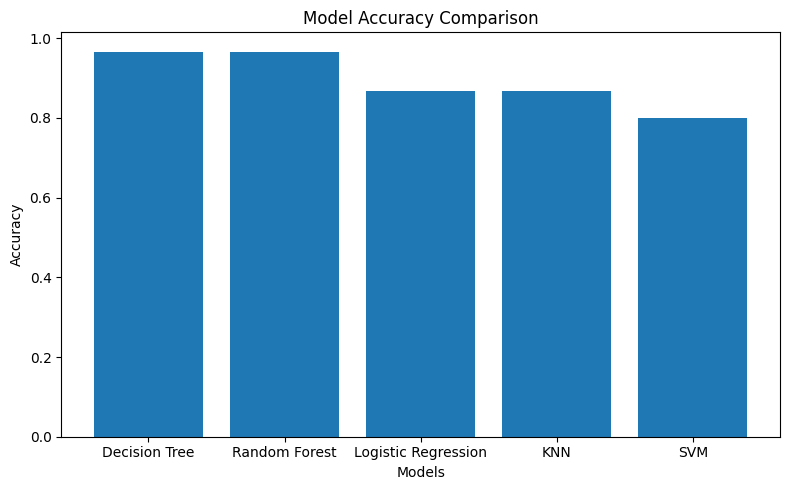

In [42]:
import matplotlib.pyplot as plt

plot_df = result_df.sort_values("Accuracy", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(plot_df["Model"], plot_df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()